In [ ]:
import pandas as pd

df = pd.read_csv("wolfflin_principle_annotations.csv")
print(df.head())
print(df.shape)
print(df.describe())

FileNotFoundError: [Errno 2] No such file or directory: 'wolfflin_principle_annotations.csv'

In [ ]:
import pandas as pd

df = pd.read_csv("wolfflin_principle_annotations.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [ ]:
wide = df.pivot_table(
    index=["art_url", "type"],
    columns="wolfflin_principle",
    values="selected",
    aggfunc="mean"
).reset_index()

print(wide.head())
print(wide.shape)

wolfflin_principle                                            art_url  type  \
0                   https://crw2020.s3-us-west-2.amazonaws.com/ran...  real   
1                   https://crw2020.s3-us-west-2.amazonaws.com/ran...  real   
2                   https://crw2020.s3-us-west-2.amazonaws.com/ran...  real   
3                   https://crw2020.s3-us-west-2.amazonaws.com/ran...  real   
4                   https://crw2020.s3-us-west-2.amazonaws.com/ran...  real   

wolfflin_principle  absolute-vs-relative  closed-form-vs-open-form  \
0                                    1.2                       2.2   
1                                    4.6                       2.2   
2                                    1.2                       1.8   
3                                    4.0                       1.8   
4                                    3.4                       4.0   

wolfflin_principle  linearly-vs-painterly  multiplicity-vs-unity  \
0                                   

In [ ]:
wide_clean = wide.copy()

wide_clean = wide_clean.rename(columns={
    "linearly-vs-painterly": "Linear vs Painterly",
    "planar-vs-recessional": "Planar vs Recessional",
    "closed-form-vs-open-form": "Closed vs Open Form",
    "multiplicity-vs-unity": "Multiplicity vs Unity",
    "absolute-vs-relative": "Absolute vs Relative"
})

# Creiamo un ID immagine
wide_clean["image_id"] = range(1, len(wide_clean) + 1)

# Riordiniamo le colonne
cols = ["image_id", "art_url",
        "Linear vs Painterly",
        "Planar vs Recessional",
        "Closed vs Open Form",
        "Multiplicity vs Unity",
        "Absolute vs Relative"]

wide_clean = wide_clean[cols]

wide_clean.head(10)

wolfflin_principle,image_id,art_url,Linear vs Painterly,Planar vs Recessional,Closed vs Open Form,Multiplicity vs Unity,Absolute vs Relative
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4
5,6,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,4.4,4.4,4.2,3.4
6,7,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.4,5.0,3.6,4.8,4.6
7,8,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.4,3.6,4.4,4.4,3.8
8,9,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.6,2.4,2.8,1.8
9,10,https://crw2020.s3-us-west-2.amazonaws.com/ran...,5.0,3.6,4.4,3.2,2.8


In [ ]:
import os, re, json, time
import pandas as pd
import numpy as np
import requests
from urllib.parse import urlparse

BASE_DIR = "/content"
IMG_DIR = os.path.join(BASE_DIR, "waga_images")
OUT_DIR = os.path.join(BASE_DIR, "waga_out")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

STATE_JSON = os.path.join(OUT_DIR, "waga_wolfflin_analyzed.json")
OUT_CSV    = os.path.join(OUT_DIR, "waga_wolfflin_predictions.csv")
FAIL_CSV   = os.path.join(OUT_DIR, "waga_failed_downloads.csv")

print("IMG_DIR:", IMG_DIR)
print("OUT_DIR:", OUT_DIR)

IMG_DIR: /content/waga_images
OUT_DIR: /content/waga_out


In [ ]:
df = pd.read_csv("wolfflin_principle_annotations.csv").drop(columns=["Unnamed: 0"], errors="ignore")

wide = df.pivot_table(
    index=["art_url", "type"],
    columns="wolfflin_principle",
    values="selected",
    aggfunc="mean"
).reset_index()

wide_clean = wide.rename(columns={
    "linearly-vs-painterly": "Linear vs Painterly",
    "planar-vs-recessional": "Planar vs Recessional",
    "closed-form-vs-open-form": "Closed vs Open Form",
    "multiplicity-vs-unity": "Multiplicity vs Unity",
    "absolute-vs-relative": "Absolute vs Relative"
})


wide_clean = wide_clean.reset_index(drop=True)
wide_clean["image_id"] = wide_clean.index + 1

cols = ["image_id","art_url",
        "Linear vs Painterly",
        "Planar vs Recessional",
        "Closed vs Open Form",
        "Multiplicity vs Unity",
        "Absolute vs Relative"]

wide_clean = wide_clean[cols]

print("Righe:", len(wide_clean))
wide_clean.head()

Righe: 1800


wolfflin_principle,image_id,art_url,Linear vs Painterly,Planar vs Recessional,Closed vs Open Form,Multiplicity vs Unity,Absolute vs Relative
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4


In [ ]:
wide["type"].value_counts(dropna=False)

,count
type,
real,1000
generated,800


In [ ]:
wide_real = wide[wide["type"] == "real"].copy()
print("Righe REAL:", len(wide_real))

wide_clean_real = wide_real.rename(columns={
    "linearly-vs-painterly": "Linear vs Painterly",
    "planar-vs-recessional": "Planar vs Recessional",
    "closed-form-vs-open-form": "Closed vs Open Form",
    "multiplicity-vs-unity": "Multiplicity vs Unity",
    "absolute-vs-relative": "Absolute vs Relative"
}).reset_index(drop=True)

wide_clean_real["image_id"] = wide_clean_real.index + 1

cols = ["image_id","art_url",
        "Linear vs Painterly",
        "Planar vs Recessional",
        "Closed vs Open Form",
        "Multiplicity vs Unity",
        "Absolute vs Relative"]

wide_clean_real = wide_clean_real[cols]

wide_clean_real.head()

Righe REAL: 1000


wolfflin_principle,image_id,art_url,Linear vs Painterly,Planar vs Recessional,Closed vs Open Form,Multiplicity vs Unity,Absolute vs Relative
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4


In [ ]:
OUT_REAL = "/content/waga_real_1000_for_second_prompt.csv"
wide_clean_real.to_csv(OUT_REAL, index=False)
print("Salvato:", OUT_REAL, "| righe:", len(wide_clean_real))

NameError: name 'wide_clean_real' is not defined

In [ ]:
!pip -q install --upgrade google-generativeai pillow pandas requests

In [ ]:
import os
from getpass import getpass

os.environ["GOOGLE_API_KEY"] = getpass("Inserisci la tua GOOGLE_API_KEY: ")

Inserisci la tua GOOGLE_API_KEY: ··········


In [ ]:
import os, json, time, random, requests
from io import BytesIO
from datetime import datetime, timezone

import pandas as pd
from PIL import Image
import google.generativeai as genai

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

MODEL_NAME = "gemini-2.5-flash"
model = genai.GenerativeModel(MODEL_NAME)

print("MODEL_NAME:", MODEL_NAME)

MODEL_NAME: gemini-2.5-flash


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
WGA_CSV = "/content/waga_real_1000_for_second_prompt.csv"

df_wga = pd.read_csv(WGA_CSV)

print("Numero opere nel file:", len(df_wga))
display(df_wga.head())

Numero opere nel file: 1000


,image_id,art_url,Linear vs Painterly,Planar vs Recessional,Closed vs Open Form,Multiplicity vs Unity,Absolute vs Relative
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4


In [ ]:
tot_opere = len(df_wga)
print("Totale opere da analizzare:", tot_opere)

Totale opere da analizzare: 1000


In [ ]:
PROMPT_2 = """
You are an art history expert.

Analyze the provided artwork image carefully.

Respond ONLY in valid JSON format.
Do not include explanations outside the JSON.
If unsure, make your best reasoned hypothesis.
If a category does not fit any option, use "Unknown".

Provide:

1) artist_guess:
   - Provide exactly 3 possible artists.
   - Order them from most probable to least probable.

2) macro_style:
   Choose ONLY one from this list:
   [
   "Abstract (large family)",
   "Academic / Traditional",
   "Art Nouveau / Deco",
   "Asian Traditional",
   "Baroque",
   "Constructivist / Geometric Modern",
   "Contemporary Media",
   "Cubism",
   "Expressionism",
   "Feminist / Identity",
   "Futurism",
   "Impressionism",
   "Medieval",
   "Modernism",
   "Muralism",
   "Naturalism / Luminism / Tonalism",
   "Naïve",
   "Neoclassicism / Classicism",
   "Pop / Dada / Postmodern",
   "Realism",
   "Renaissance",
   "Romanticism",
   "Surrealism / Metaphysical",
   "Symbolism / Intimism",
   ]

3) technique:
   Choose ONLY one from:
   [
   "oil",
   "tempera",
   "fresco",
   "drawing",
   "pastel",
   "watercolour",
   "encaustic",
   ]

4) genre:
   Choose ONLY one:
   [
   "historical",
   "interior",
   "landscape",
   "mythological",
   "other",
   "genre"
   "portrait",
   "religious",
   "still-life",
   "study"
   ]

5) school:
   Choose ONLY one:
   [
   "american",
   "austrian",
   "belgian",
   "bohemian",
   "catalan",
   "danish",
   "dutch",
   "english",
   "finnish",
   "flemish",
   "french",
   "german",
   "greek",
   "hungarian",
   "irish",
   "italian",
   "netherlandish",
   "norwegian",
   "other",
   "polish",
   "portuguese",
   "russian",
   "scottish",
   "spanish",
   "swedish",
   "swiss"
   ]

6) historical_period:
   Choose one of these ranges if applicable.
   If clearly before or after, estimate the closest period.

   [
   "0751-0800","0801-0850","0851-0900","0951-1000",
   "1001-1050","1051-1100","1101-1150","1151-1200",
   "1201-1250","1251-1300","1301-1350","1351-1400",
   "1401-1450","1451-1500","1501-1550","1551-1600",
   "1601-1650","1651-1700","1701-1750","1751-1800",
   "1801-1850","1851-1900"
   ]

7) wolfflin_principles:

For each pair, rate the artwork on a scale from 1 to 5.

Use this scale for ALL pairs:

1 = Clearly first pole
2 = Mostly first pole
3 = Balanced / Borderline
4 = Mostly second pole
5 = Clearly second pole

Respond ONLY with an integer from 1 to 5 for each pair.

Pairs:

- linear_vs_painterly
  (1 = clearly linear, 5 = clearly painterly)

- plane_vs_recession
  (1 = clearly planar, 5 = clearly recessional)

- closed_vs_open_form
  (1 = clearly closed form, 5 = clearly open form)

- multiplicity_vs_unity
  (1 = clearly multiplicity, 5 = clearly unity)

- absolute_vs_relative_clarity
  (1 = clearly absolute clarity, 5 = clearly relative clarity)

8) short_description:
   Provide a brief (max 80 words) objective description of what is visible in the artwork.

Return strictly this JSON structure:

{
  "artist_guess": ["Name1", "Name2", "Name3"],
  "macro_style": "...",
  "technique": "...",
  "genre": "...",
  "school": "...",
  "historical_period": "...",
  "wolfflin_principles": {
      "linear_vs_painterly": "...",
      "plane_vs_recession": "...",
      "closed_vs_open_form": "...",
      "multiplicity_vs_unity": "...",
      "absolute_vs_relative_clarity": "..."
  },
  "short_description": "..."
}
"""

In [ ]:
OUT_DIR = "/content/wga_gemini_run"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_JSONL = os.path.join(OUT_DIR, "results_wga_gemini.jsonl")
STATE_JSON = os.path.join(OUT_DIR, "state_wga_gemini.json")
OUT_CSV = os.path.join(OUT_DIR, "results_wga_gemini.csv")

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /content/wga_gemini_run


In [ ]:
def download_image_from_url(url, timeout=30):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, timeout=timeout, headers=headers)
    r.raise_for_status()
    return r.content

def prepare_image_bytes_for_gemini(image_bytes, max_side=1600, jpeg_quality=90):
    img = Image.open(BytesIO(image_bytes))


    if img.mode != "RGB":
        img = img.convert("RGB")

    # ridimensiona
    w, h = img.size
    scale = min(max_side / max(w, h), 1.0)
    if scale < 1.0:
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

    # salva come JPEG
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=jpeg_quality)
    return buf.getvalue()

def extract_json_from_text(text):
    if not text or not str(text).strip():
        raise ValueError("EMPTY_RESPONSE_TEXT")

    t = str(text).strip()

    if t.startswith("```json"):
        t = t[7:]
    if t.startswith("```"):
        t = t[3:]
    if t.endswith("```"):
        t = t[:-3]

    t = t.strip()

    try:
        return json.loads(t)
    except:
        pass

    start = t.find("{")
    end = t.rfind("}")
    if start != -1 and end != -1 and end > start:
        return json.loads(t[start:end+1])

    raise ValueError("NO_JSON_FOUND")

def analyze_image_gemini(image_url, prompt_text, max_retries=2):
    last_err = None

    for _ in range(max_retries):
        try:
            raw_bytes = download_image_from_url(image_url)
            clean_jpeg_bytes = prepare_image_bytes_for_gemini(raw_bytes)

            resp = model.generate_content(
                [
                    prompt_text,
                    {
                        "mime_type": "image/jpeg",
                        "data": clean_jpeg_bytes
                    }
                ],
                generation_config={
                    "temperature": 0,
                    "response_mime_type": "application/json",
                }
            )

            raw_text = resp.text
            pred = extract_json_from_text(raw_text)
            return pred, raw_text

        except Exception as e:
            last_err = str(e)
            time.sleep(1 + random.uniform(0, 0.5))

    raise ValueError(last_err or "GEMINI_CALL_FAILED")

In [ ]:
def get_done_images(path):
    done = set()
    ok_count = 0

    if not os.path.exists(path):
        return done, 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is True:
                    done.add(str(rec.get("image_id")))
                    ok_count += 1
            except:
                pass

    return done, ok_count

done_images, already_ok = get_done_images(OUT_JSONL)

print("Opere già analizzate:", already_ok)
print("Opere ancora da analizzare:", len(df_wga) - already_ok)

Opere già analizzate: 553
Opere ancora da analizzare: 447


In [ ]:
N_OPERE = 1000
SAVE_STATE_EVERY = 10

RPM_TARGET = 60
MIN_SECONDS = 60 / RPM_TARGET

print("N_OPERE:", N_OPERE)
print("SAVE_STATE_EVERY:", SAVE_STATE_EVERY)
print("MIN_SECONDS:", MIN_SECONDS)

N_OPERE: 1000
SAVE_STATE_EVERY: 10
MIN_SECONDS: 1.0


In [ ]:
processed_ok = 0
processed_err = 0

def save_state(last_image_id=None):
    st = {
        "dataset": "wga_real_1000",
        "model": MODEL_NAME,
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "done_ok_total": already_ok + processed_ok,
        "processed_ok_this_run": processed_ok,
        "processed_err_this_run": processed_err,
        "last_image_id": last_image_id,
    }
    with open(STATE_JSON, "w", encoding="utf-8") as f:
        json.dump(st, f, ensure_ascii=False, indent=2)

with open(OUT_JSONL, "a", encoding="utf-8") as f_out:
    for _, row in df_wga.head(N_OPERE).iterrows():
        image_id = str(row["image_id"])
        image_url = row["art_url"]

        if image_id in done_images:
            continue

        t0 = time.time()

        rec = {
            "dataset": "wga_real_1000",
            "model": MODEL_NAME,
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "image_id": image_id,
            "art_url": image_url,
            "true_linear_vs_painterly": row.get("Linear vs Painterly"),
            "true_planar_vs_recessional": row.get("Planar vs Recessional"),
            "true_closed_vs_open_form": row.get("Closed vs Open Form"),
            "true_multiplicity_vs_unity": row.get("Multiplicity vs Unity"),
            "true_absolute_vs_relative": row.get("Absolute vs Relative"),
            "pred": None,
            "gemini_raw": None,
            "ok": False,
            "error": None,
        }

        try:
            pred, raw = analyze_image_gemini(image_url, PROMPT_2)
            rec["pred"] = pred
            rec["gemini_raw"] = raw
            rec["ok"] = True

            processed_ok += 1
            done_images.add(image_id)

            print(f"[OK] {already_ok + processed_ok}/{len(df_wga)} -> image_id {image_id}")

        except Exception as e:
            rec["error"] = str(e)
            processed_err += 1
            print(f"[ERR] {already_ok + processed_ok}/{len(df_wga)} -> image_id {image_id} | {str(e)[:150]}")

        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")
        f_out.flush()

        if (processed_ok + processed_err) % SAVE_STATE_EVERY == 0:
            save_state(last_image_id=image_id)
            print("Progress:", processed_ok, "ok |", processed_err, "err | ok total:", already_ok + processed_ok)

        elapsed = time.time() - t0
        sleep_time = max(0, MIN_SECONDS - elapsed) + random.uniform(0, 0.2)
        time.sleep(sleep_time)

save_state()
print("FINE RUN | ok:", processed_ok, "err:", processed_err, "ok total:", already_ok + processed_ok)

[ERR] 553/1000 -> image_id 403 | Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.
This appears to be caused 
[ERR] 553/1000 -> image_id 521 | Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.
This appears to be caused 
[OK] 554/1000 -> image_id 556
[OK] 555/1000 -> image_id 557
[OK] 556/1000 -> image_id 558
[OK] 557/1000 -> image_id 559
[OK] 558/1000 -> image_id 560
[OK] 559/1000 -> image_id 561
[OK] 560/1000 -> image_id 562
[OK] 561/1000 -> image_id 563
Progress: 8 ok | 2 err | ok total: 561
[OK] 562/1000 -> image_id 564
[OK] 563/1000 -> image_id 565
[OK] 564/1000 -> image_id 566
[OK] 565/1000 -> image_id 567
[OK] 566/1000 -> image_id 568
[OK] 567/1000 -> image_id 569
[OK] 568/1000 -> image_id 570
[OK] 569/1000 -> image_id 571
[OK] 570/1000 -> image_id 572
[OK] 571/1000 -> image_id 573
Progress: 18 ok | 2 err | ok total: 571
[OK] 572/1000

In [ ]:
rows = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            pass

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_CSV, index=False)

print("Salvato CSV:", OUT_CSV)
print("Numero righe:", len(df_out))
display(df_out.head())

Salvato CSV: /content/wga_gemini_run/results_wga_gemini.csv
Numero righe: 1026


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,gemini_raw,ok,error
0,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:26.205172+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,None,NaN,False,unsupported image mode
1,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:29.651181+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,None,NaN,False,unsupported image mode
2,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:32.664088+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,None,NaN,False,unsupported image mode
3,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:35.826063+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,None,NaN,False,unsupported image mode
4,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:39.236040+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,None,NaN,False,unsupported image mode


In [ ]:
df_check = pd.read_csv(OUT_CSV)

sample = df_check.sample(min(5, len(df_check)))

for _, row in sample.iterrows():
    print("IMAGE_ID:", row["image_id"])
    print("RISPOSTA MODELLO:")
    print(row["gemini_raw"])
    print("\n" + "-"*80 + "\n")

IMAGE_ID: 10
RISPOSTA MODELLO:
nan

--------------------------------------------------------------------------------

IMAGE_ID: 6
RISPOSTA MODELLO:
{
  "artist_guess": [
    "Armand Guillaumin",
    "Camille Pissarro",
    "Alfred Sisley"
  ],
  "macro_style": "Impressionism",
  "technique": "oil",
  "genre": "landscape",
  "school": "french",
  "historical_period": "1851-1900",
  "wolfflin_principles": {
    "linear_vs_painterly": 5,
    "plane_vs_recession": 5,
    "closed_vs_open_form": 5,
    "multiplicity_vs_unity": 4,
    "absolute_vs_relative_clarity": 5
  },
  "short_description": "A vibrant landscape painting depicts a row of rustic houses with orange roofs and textured walls lining a dirt path that recedes into the distance. A golden-yellow sky dominates the upper portion, while a lush, textured field of tall grass fills the foreground. In the background, a distinct building with a purple roof stands on a distant hill, under a hazy sky. The brushwork is loose and expressive, 

PARTE OPENAI

In [ ]:
!pip -q install --upgrade openai pandas requests pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.8 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Inserisci la tua OPENAI_API_KEY: ")

Inserisci la tua OPENAI_API_KEY: ··········


In [ ]:
import os, json, time, random, requests
from io import BytesIO
from datetime import datetime, timezone

import pandas as pd
from PIL import Image
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

MODEL_NAME = "gpt-4.1-mini"

print("MODEL_NAME:", MODEL_NAME)

MODEL_NAME: gpt-4.1-mini


In [ ]:
WGA_CSV = "/content/waga_real_1000_for_second_prompt.csv"

df_wga = pd.read_csv(WGA_CSV)

print("Numero opere nel file:", len(df_wga))
display(df_wga.head())

Numero opere nel file: 1000


,image_id,art_url,Linear vs Painterly,Planar vs Recessional,Closed vs Open Form,Multiplicity vs Unity,Absolute vs Relative
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4


In [ ]:
tot_opere = len(df_wga)
print("Totale opere da analizzare:", tot_opere)

Totale opere da analizzare: 1000


In [ ]:
OUT_DIR = "/content/wga_openai_run"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_JSONL = os.path.join(OUT_DIR, "results_wga_openai.jsonl")
STATE_JSON = os.path.join(OUT_DIR, "state_wga_openai.json")
OUT_CSV = os.path.join(OUT_DIR, "results_wga_openai.csv")

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /content/wga_openai_run


In [ ]:
def extract_json_from_text(text):
    if not text or not str(text).strip():
        raise ValueError("EMPTY_RESPONSE_TEXT")

    t = str(text).strip()

    if t.startswith("```json"):
        t = t[7:]
    if t.startswith("```"):
        t = t[3:]
    if t.endswith("```"):
        t = t[:-3]

    t = t.strip()

    try:
        return json.loads(t)
    except:
        pass

    start = t.find("{")
    end = t.rfind("}")
    if start != -1 and end != -1 and end > start:
        return json.loads(t[start:end+1])

    raise ValueError("NO_JSON_FOUND")

def analyze_image_openai(image_url, prompt_text, max_retries=2):
    last_err = None

    for _ in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=MODEL_NAME,
                temperature=0,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": prompt_text
                            },
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": image_url,
                                    "detail": "low"
                                }
                            }
                        ]
                    }
                ]
            )

            raw_text = resp.choices[0].message.content
            pred = extract_json_from_text(raw_text)
            return pred, raw_text

        except Exception as e:
            last_err = str(e)
            time.sleep(1 + random.uniform(0, 0.5))

    raise ValueError(last_err or "OPENAI_CALL_FAILED")

In [ ]:
def get_done_images(path):
    done = set()
    ok_count = 0

    if not os.path.exists(path):
        return done, 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is True:
                    done.add(str(rec.get("image_id")))
                    ok_count += 1
            except:
                pass

    return done, ok_count

done_images, already_ok = get_done_images(OUT_JSONL)

print("Opere già analizzate:", already_ok)
print("Opere ancora da analizzare:", len(df_wga) - already_ok)

Opere già analizzate: 1000
Opere ancora da analizzare: 0


In [ ]:
N_OPERE = 1000
SAVE_STATE_EVERY = 10

RPM_TARGET = 60
MIN_SECONDS = 60 / RPM_TARGET

print("N_OPERE:", N_OPERE)
print("SAVE_STATE_EVERY:", SAVE_STATE_EVERY)
print("MIN_SECONDS:", MIN_SECONDS)

N_OPERE: 1000
SAVE_STATE_EVERY: 10
MIN_SECONDS: 1.0


In [ ]:
processed_ok = 0
processed_err = 0

def save_state(last_image_id=None):
    st = {
        "dataset": "wga_real_1000",
        "model": MODEL_NAME,
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "done_ok_total": already_ok + processed_ok,
        "processed_ok_this_run": processed_ok,
        "processed_err_this_run": processed_err,
        "last_image_id": last_image_id,
    }
    with open(STATE_JSON, "w", encoding="utf-8") as f:
        json.dump(st, f, ensure_ascii=False, indent=2)

with open(OUT_JSONL, "a", encoding="utf-8") as f_out:
    for _, row in df_wga.head(N_OPERE).iterrows():
        image_id = str(row["image_id"])
        image_url = row["art_url"]

        if image_id in done_images:
            continue

        t0 = time.time()

        rec = {
            "dataset": "wga_real_1000",
            "model": MODEL_NAME,
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "image_id": image_id,
            "art_url": image_url,
            "true_linear_vs_painterly": row.get("Linear vs Painterly"),
            "true_planar_vs_recessional": row.get("Planar vs Recessional"),
            "true_closed_vs_open_form": row.get("Closed vs Open Form"),
            "true_multiplicity_vs_unity": row.get("Multiplicity vs Unity"),
            "true_absolute_vs_relative": row.get("Absolute vs Relative"),
            "pred": None,
            "openai_raw": None,
            "ok": False,
            "error": None,
        }

        try:
            pred, raw = analyze_image_openai(image_url, PROMPT_2)
            rec["pred"] = pred
            rec["openai_raw"] = raw
            rec["ok"] = True

            processed_ok += 1
            done_images.add(image_id)

            print(f"[OK] {already_ok + processed_ok}/{len(df_wga)} -> image_id {image_id}")

        except Exception as e:
            rec["error"] = str(e)
            processed_err += 1
            print(f"[ERR] {already_ok + processed_ok}/{len(df_wga)} -> image_id {image_id} | {str(e)[:150]}")

        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")
        f_out.flush()

        if (processed_ok + processed_err) % SAVE_STATE_EVERY == 0:
            save_state(last_image_id=image_id)
            print("Progress:", processed_ok, "ok |", processed_err, "err | ok total:", already_ok + processed_ok)

        elapsed = time.time() - t0
        sleep_time = max(0, MIN_SECONDS - elapsed) + random.uniform(0, 0.2)
        time.sleep(sleep_time)

save_state()
print("FINE RUN | ok:", processed_ok, "err:", processed_err, "ok total:", already_ok + processed_ok)

[OK] 1/1000 -> image_id 21
[OK] 2/1000 -> image_id 22
[OK] 3/1000 -> image_id 23
[OK] 4/1000 -> image_id 24
[OK] 5/1000 -> image_id 25
[OK] 6/1000 -> image_id 26
[OK] 7/1000 -> image_id 27
[OK] 8/1000 -> image_id 28
[OK] 9/1000 -> image_id 29
[OK] 10/1000 -> image_id 30
Progress: 10 ok | 0 err | ok total: 10
[OK] 11/1000 -> image_id 31
[OK] 12/1000 -> image_id 32
[OK] 13/1000 -> image_id 33
[OK] 14/1000 -> image_id 34
[OK] 15/1000 -> image_id 35
[OK] 16/1000 -> image_id 36
[OK] 17/1000 -> image_id 37
[OK] 18/1000 -> image_id 38
[OK] 19/1000 -> image_id 39
[OK] 20/1000 -> image_id 40
Progress: 20 ok | 0 err | ok total: 20
[OK] 21/1000 -> image_id 41
[OK] 22/1000 -> image_id 42
[OK] 23/1000 -> image_id 43
[OK] 24/1000 -> image_id 44
[OK] 25/1000 -> image_id 45
[OK] 26/1000 -> image_id 46
[OK] 27/1000 -> image_id 47
[OK] 28/1000 -> image_id 48
[OK] 29/1000 -> image_id 49
[OK] 30/1000 -> image_id 50
Progress: 30 ok | 0 err | ok total: 30
[OK] 31/1000 -> image_id 51
[OK] 32/1000 -> image_id

In [ ]:
rows = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            pass

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_CSV, index=False)

print("Salvato CSV:", OUT_CSV)
print("Numero righe:", len(df_out))
display(df_out.head())

Salvato CSV: /content/wga_openai_run/results_wga_openai.csv
Numero righe: 1000


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,openai_raw,ok,error
0,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:13.172574+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Raphael', 'Andrea del Sarto...","```json\n{\n ""artist_guess"": [""Raphael"", ""And...",True,None
1,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:18.700891+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Titian', 'Paolo Veronese', ...","```json\n{\n ""artist_guess"": [""Titian"", ""Paol...",True,None
2,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:25.914152+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Frans Hals', 'Rembrandt van...","```json\n{\n ""artist_guess"": [""Frans Hals"", ""...",True,None
3,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:31.202588+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Hans Memling', 'Rogier van ...","```json\n{\n ""artist_guess"": [""Hans Memling"",...",True,None
4,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:35.144364+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Camille Pissarro', 'Alfred ...","```json\n{\n ""artist_guess"": [""Camille Pissar...",True,None


In [ ]:
df_check = pd.read_csv(OUT_CSV)

sample = df_check.sample(min(5, len(df_check)))

for _, row in sample.iterrows():
    print("IMAGE_ID:", row["image_id"])
    print("RISPOSTA MODELLO:")
    print(row["openai_raw"])
    print("\n" + "-"*80 + "\n")

IMAGE_ID: 956
RISPOSTA MODELLO:
```json
{
  "artist_guess": ["Hans Memling", "Rogier van der Weyden", "Jan van Eyck"],
  "macro_style": "Northern Renaissance",
  "technique": "oil",
  "genre": "religious",
  "school": "flemish",
  "historical_period": "1451-1500",
  "wolfflin_principles": {
    "linear_vs_painterly": 1,
    "plane_vs_recession": 4,
    "closed_vs_open_form": 2,
    "multiplicity_vs_unity": 2,
    "absolute_vs_relative_clarity": 1
  },
  "short_description": "A religious scene featuring Christ and a crowned female figure holding a globe, a lamb, and a dove, surrounded by symbolic elements including an eye in a fiery halo and a book, rendered with detailed, precise oil painting typical of Northern Renaissance art."
}
```

--------------------------------------------------------------------------------

IMAGE_ID: 12
RISPOSTA MODELLO:
```json
{
  "artist_guess": ["Giotto di Bondone", "Cimabue", "Duccio di Buoninsegna"],
  "macro_style": "Medieval",
  "technique": "tempera"

PARTE CLAUDE

In [ ]:
!pip -q install --upgrade anthropic pandas pillow requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have

In [ ]:
import os
from getpass import getpass

os.environ["ANTHROPIC_API_KEY"] = getpass("Inserisci la tua ANTHROPIC_API_KEY: ")

KeyboardInterrupt: Interrupted by user

In [ ]:
import os, json, time, random, requests, base64
from io import BytesIO
from datetime import datetime, timezone

import pandas as pd
from PIL import Image
from anthropic import Anthropic

client_claude = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

MODEL_NAME = "claude-haiku-4-5"

print("MODEL_NAME:", MODEL_NAME)

MODEL_NAME: claude-haiku-4-5


In [ ]:
WGA_CSV = "/content/waga_real_1000_for_second_prompt.csv"

df_wga = pd.read_csv(WGA_CSV)

print("Numero opere nel file:", len(df_wga))
display(df_wga.head())

Numero opere nel file: 1000


,image_id,art_url,Linear vs Painterly,Planar vs Recessional,Closed vs Open Form,Multiplicity vs Unity,Absolute vs Relative
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4


In [ ]:
tot_opere = len(df_wga)
print("Totale opere da analizzare:", tot_opere)

Totale opere da analizzare: 1000


In [ ]:
OUT_DIR = "/content/wga_claude_run"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_JSONL = os.path.join(OUT_DIR, "results_wga_claude.jsonl")
STATE_JSON = os.path.join(OUT_DIR, "state_wga_claude.json")
OUT_CSV = os.path.join(OUT_DIR, "results_wga_claude.csv")

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /content/wga_claude_run


In [ ]:
def download_image_from_url(url, timeout=30):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, timeout=timeout, headers=headers)
    r.raise_for_status()
    return r.content

def prepare_image_base64_for_claude(image_bytes, max_side=1024, jpeg_quality=85):
    img = Image.open(BytesIO(image_bytes))

    if img.mode != "RGB":
        img = img.convert("RGB")

    w, h = img.size
    scale = min(max_side / max(w, h), 1.0)
    if scale < 1.0:
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

    buf = BytesIO()
    img.save(buf, format="JPEG", quality=jpeg_quality, optimize=True)
    jpeg_bytes = buf.getvalue()

    return base64.b64encode(jpeg_bytes).decode("utf-8"), "image/jpeg"

def extract_json_from_text(text):
    if not text or not str(text).strip():
        raise ValueError("EMPTY_RESPONSE_TEXT")

    t = str(text).strip()

    if t.startswith("```json"):
        t = t[7:]
    if t.startswith("```"):
        t = t[3:]
    if t.endswith("```"):
        t = t[:-3]

    t = t.strip()

    try:
        return json.loads(t)
    except:
        pass

    start = t.find("{")
    end = t.rfind("}")
    if start != -1 and end != -1 and end > start:
        return json.loads(t[start:end+1])

    raise ValueError("NO_JSON_FOUND")

def analyze_image_claude(image_url, prompt_text, max_retries=2):
    last_err = None

    for _ in range(max_retries):
        try:
            raw_bytes = download_image_from_url(image_url)
            image_b64, media_type = prepare_image_base64_for_claude(raw_bytes)

            resp = client_claude.messages.create(
                model=MODEL_NAME,
                max_tokens=350,
                temperature=0,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "image",
                                "source": {
                                    "type": "base64",
                                    "media_type": media_type,
                                    "data": image_b64,
                                },
                            },
                            {
                                "type": "text",
                                "text": prompt_text,
                            },
                        ],
                    }
                ],
            )

            raw_text = ""
            for block in resp.content:
                if getattr(block, "type", None) == "text":
                    raw_text += block.text

            pred = extract_json_from_text(raw_text)
            return pred, raw_text

        except Exception as e:
            last_err = str(e)
            time.sleep(1 + random.uniform(0, 0.5))

    raise ValueError(last_err or "CLAUDE_CALL_FAILED")

In [ ]:
def get_done_images(path):
    done = set()
    ok_count = 0

    if not os.path.exists(path):
        return done, 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is True:
                    done.add(str(rec.get("image_id")))
                    ok_count += 1
            except:
                pass

    return done, ok_count

done_images, already_ok = get_done_images(OUT_JSONL)

print("Opere già analizzate:", already_ok)
print("Opere ancora da analizzare:", len(df_wga) - already_ok)

Opere già analizzate: 20
Opere ancora da analizzare: 980


In [ ]:
N_OPERE = 1000
SAVE_STATE_EVERY = 10

RPM_TARGET = 50
MIN_SECONDS = 60 / RPM_TARGET

print("N_OPERE:", N_OPERE)
print("SAVE_STATE_EVERY:", SAVE_STATE_EVERY)
print("MIN_SECONDS:", MIN_SECONDS)

N_OPERE: 1000
SAVE_STATE_EVERY: 10
MIN_SECONDS: 1.2


In [ ]:
processed_ok = 0
processed_err = 0

def save_state(last_image_id=None):
    st = {
        "dataset": "wga_real_1000",
        "model": MODEL_NAME,
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "done_ok_total": already_ok + processed_ok,
        "processed_ok_this_run": processed_ok,
        "processed_err_this_run": processed_err,
        "last_image_id": last_image_id,
    }
    with open(STATE_JSON, "w", encoding="utf-8") as f:
        json.dump(st, f, ensure_ascii=False, indent=2)

with open(OUT_JSONL, "a", encoding="utf-8") as f_out:
    for _, row in df_wga.head(N_OPERE).iterrows():
        image_id = str(row["image_id"])
        image_url = row["art_url"]

        if image_id in done_images:
            continue

        t0 = time.time()

        rec = {
            "dataset": "wga_real_1000",
            "model": MODEL_NAME,
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "image_id": image_id,
            "art_url": image_url,
            "true_linear_vs_painterly": row.get("Linear vs Painterly"),
            "true_planar_vs_recessional": row.get("Planar vs Recessional"),
            "true_closed_vs_open_form": row.get("Closed vs Open Form"),
            "true_multiplicity_vs_unity": row.get("Multiplicity vs Unity"),
            "true_absolute_vs_relative": row.get("Absolute vs Relative"),
            "pred": None,
            "claude_raw": None,
            "ok": False,
            "error": None,
        }

        try:
            pred, raw = analyze_image_claude(image_url, PROMPT_2)
            rec["pred"] = pred
            rec["claude_raw"] = raw
            rec["ok"] = True

            processed_ok += 1
            done_images.add(image_id)

            print(f"[OK] {already_ok + processed_ok}/{len(df_wga)} -> image_id {image_id}")

        except Exception as e:
            rec["error"] = str(e)
            processed_err += 1
            print(f"[ERR] {already_ok + processed_ok}/{len(df_wga)} -> image_id {image_id} | {str(e)[:150]}")

        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")
        f_out.flush()

        if (processed_ok + processed_err) % SAVE_STATE_EVERY == 0:
            save_state(last_image_id=image_id)
            print("Progress:", processed_ok, "ok |", processed_err, "err | ok total:", already_ok + processed_ok)

        elapsed = time.time() - t0
        sleep_time = max(0, MIN_SECONDS - elapsed) + random.uniform(0, 0.2)
        time.sleep(sleep_time)

save_state()
print("FINE RUN | ok:", processed_ok, "err:", processed_err, "ok total:", already_ok + processed_ok)

[OK] 21/1000 -> image_id 21
[OK] 22/1000 -> image_id 22
[OK] 23/1000 -> image_id 23
[OK] 24/1000 -> image_id 24
[OK] 25/1000 -> image_id 25
[OK] 26/1000 -> image_id 26
[OK] 27/1000 -> image_id 27
[OK] 28/1000 -> image_id 28
[OK] 29/1000 -> image_id 29
[OK] 30/1000 -> image_id 30
Progress: 10 ok | 0 err | ok total: 30
[OK] 31/1000 -> image_id 31
[OK] 32/1000 -> image_id 32
[OK] 33/1000 -> image_id 33
[OK] 34/1000 -> image_id 34
[OK] 35/1000 -> image_id 35
[OK] 36/1000 -> image_id 36
[OK] 37/1000 -> image_id 37
[OK] 38/1000 -> image_id 38
[OK] 39/1000 -> image_id 39
[OK] 40/1000 -> image_id 40
Progress: 20 ok | 0 err | ok total: 40
[OK] 41/1000 -> image_id 41
[OK] 42/1000 -> image_id 42
[OK] 43/1000 -> image_id 43
[OK] 44/1000 -> image_id 44
[OK] 45/1000 -> image_id 45
[OK] 46/1000 -> image_id 46
[OK] 47/1000 -> image_id 47
[OK] 48/1000 -> image_id 48
[OK] 49/1000 -> image_id 49
[OK] 50/1000 -> image_id 50
Progress: 30 ok | 0 err | ok total: 50
[OK] 51/1000 -> image_id 51
[OK] 52/1000 ->

In [ ]:
rows = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            pass

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_CSV, index=False)

print("Salvato CSV:", OUT_CSV)
print("Numero righe:", len(df_out))
display(df_out.head())

Salvato CSV: /content/wga_claude_run/results_wga_claude.csv
Numero righe: 1000


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,claude_raw,ok,error
0,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:10.921083+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Bartolomé Bermejo', 'Pedro ...","```json\n{\n ""artist_guess"": [\n ""Bartolom...",True,None
1,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:14.267393+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Paolo Veronese', 'Jacopo Ti...","```json\n{\n ""artist_guess"": [""Paolo Veronese...",True,None
2,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:17.208737+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Francisco Goya', 'Diego Vel...","```json\n{\n ""artist_guess"": [""Francisco Goya...",True,None
3,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:19.885336+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Carlo Crivelli', 'Francesco...","```json\n{\n ""artist_guess"": [\n ""Carlo Cr...",True,None
4,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:23.008126+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Egon Schiele', 'Oskar Kokos...","```json\n{\n ""artist_guess"": [""Egon Schiele"",...",True,None


In [ ]:
df_check = pd.read_csv(OUT_CSV)

sample = df_check.sample(min(5, len(df_check)))

for _, row in sample.iterrows():
    print("IMAGE_ID:", row["image_id"])
    print("RISPOSTA MODELLO:")
    print(row["claude_raw"])
    print("\n" + "-"*80 + "\n")

IMAGE_ID: 354
RISPOSTA MODELLO:
```json
{
  "artist_guess": ["Masaccio", "Paolo Uccello", "Masolino da Panicale"],
  "macro_style": "Renaissance",
  "technique": "fresco",
  "genre": "portrait",
  "school": "italian",
  "historical_period": "1401-1450",
  "wolfflin_principles": {
    "linear_vs_painterly": 2,
    "plane_vs_recession": 2,
    "closed_vs_open_form": 1,
    "multiplicity_vs_unity": 5,
    "absolute_vs_relative_clarity": 2
  },
  "short_description": "A Renaissance fresco portrait of a bald man with a solemn expression, rendered in three-quarter view. The figure wears an orange halo and is set within concentric circular frames. The technique demonstrates early Renaissance mastery of form, volume, and psychological depth through careful modeling and restrained color palette."
}
```

--------------------------------------------------------------------------------

IMAGE_ID: 198
RISPOSTA MODELLO:
```json
{
  "artist_guess": [
    "Richard Wilson",
    "Thomas Gainsborough",
 

In [ ]:
df_waga_truth = pd.read_csv("/content/waga_real_1000_for_second_prompt.csv")

df_waga_truth = df_waga_truth.rename(columns={
    "Linear vs Painterly": "true_linear_vs_painterly",
    "Planar vs Recessional": "true_planar_vs_recessional",
    "Closed vs Open Form": "true_closed_vs_open_form",
    "Multiplicity vs Unity": "true_multiplicity_vs_unity",
    "Absolute vs Relative": "true_absolute_vs_relative_clarity"
}).copy()

print(df_waga_truth.shape)
display(df_waga_truth.head())

(1000, 7)


,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative_clarity
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4


In [ ]:
import pandas as pd

df_waga_gem = pd.read_csv("/content/results_wga_gemini.csv")

print("Shape:", df_waga_gem.shape)
display(df_waga_gem.head())
print(df_waga_gem.columns.tolist())

Shape: (1026, 14)


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,gemini_raw,ok,error
0,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:26.205172+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,NaN,NaN,False,unsupported image mode
1,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:29.651181+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,NaN,NaN,False,unsupported image mode
2,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:32.664088+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,NaN,NaN,False,unsupported image mode
3,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:35.826063+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,NaN,NaN,False,unsupported image mode
4,wga_real_1000,gemini-2.5-flash,2026-03-08T16:55:39.236040+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,NaN,NaN,False,unsupported image mode


['dataset', 'model', 'timestamp_utc', 'image_id', 'art_url', 'true_linear_vs_painterly', 'true_planar_vs_recessional', 'true_closed_vs_open_form', 'true_multiplicity_vs_unity', 'true_absolute_vs_relative', 'pred', 'gemini_raw', 'ok', 'error']


In [ ]:
print("Totale righe:", len(df_waga_gem))
print("Risposte valide:", df_waga_gem["ok"].sum())
print("Errori:", (~df_waga_gem["ok"]).sum())

Totale righe: 1026
Risposte valide: 996
Errori: 30


In [ ]:
df_waga_gem_valid = df_waga_gem[df_waga_gem["ok"] == True].copy()

print("Righe valide:", len(df_waga_gem_valid))
display(df_waga_gem_valid.head())

Righe valide: 996


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,gemini_raw,ok,error
21,wga_real_1000,gemini-2.5-flash,2026-03-08T17:04:40.803691+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Giulio Romano', 'Parmigiani...","{\n ""artist_guess"": [\n ""Giulio Romano"",\n...",True,NaN
22,wga_real_1000,gemini-2.5-flash,2026-03-08T17:04:53.229271+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Tintoretto', 'Paolo Verones...","{\n ""artist_guess"": [\n ""Tintoretto"",\n ...",True,NaN
23,wga_real_1000,gemini-2.5-flash,2026-03-08T17:05:04.407210+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Rembrandt van Rijn', 'Frans...","{\n ""artist_guess"": [\n ""Rembrandt van Rij...",True,NaN
24,wga_real_1000,gemini-2.5-flash,2026-03-08T17:05:11.238690+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Andrea Mantegna', 'Carlo Cr...","{\n ""artist_guess"": [\n ""Andrea Mantegna"",...",True,NaN
25,wga_real_1000,gemini-2.5-flash,2026-03-08T17:05:20.258780+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Paul Signac', 'Camille Piss...","{\n ""artist_guess"": [\n ""Paul Signac"",\n ...",True,NaN


In [ ]:
df_waga_gem_valid = df_waga_gem[df_waga_gem["ok"] == True].copy()

print("Righe valide:", len(df_waga_gem_valid))
display(df_waga_gem_valid.head())

Righe valide: 996


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,gemini_raw,ok,error
21,wga_real_1000,gemini-2.5-flash,2026-03-08T17:04:40.803691+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Giulio Romano', 'Parmigiani...","{\n ""artist_guess"": [\n ""Giulio Romano"",\n...",True,NaN
22,wga_real_1000,gemini-2.5-flash,2026-03-08T17:04:53.229271+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Tintoretto', 'Paolo Verones...","{\n ""artist_guess"": [\n ""Tintoretto"",\n ...",True,NaN
23,wga_real_1000,gemini-2.5-flash,2026-03-08T17:05:04.407210+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Rembrandt van Rijn', 'Frans...","{\n ""artist_guess"": [\n ""Rembrandt van Rij...",True,NaN
24,wga_real_1000,gemini-2.5-flash,2026-03-08T17:05:11.238690+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Andrea Mantegna', 'Carlo Cr...","{\n ""artist_guess"": [\n ""Andrea Mantegna"",...",True,NaN
25,wga_real_1000,gemini-2.5-flash,2026-03-08T17:05:20.258780+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Paul Signac', 'Camille Piss...","{\n ""artist_guess"": [\n ""Paul Signac"",\n ...",True,NaN


In [ ]:
for i in range(3):
    print(df_waga_gem_valid.iloc[i]["pred"])
    print("------")

{'artist_guess': ['Giulio Romano', 'Parmigianino', 'Correggio'], 'macro_style': 'Renaissance', 'technique': 'oil', 'genre': 'religious', 'school': 'italian', 'historical_period': '1501-1550', 'wolfflin_principles': {'linear_vs_painterly': 2, 'plane_vs_recession': 4, 'closed_vs_open_form': 2, 'multiplicity_vs_unity': 4, 'absolute_vs_relative_clarity': 4}, 'short_description': 'A female saint, identified by a halo, stands barefoot in a dark, rocky landscape. Dressed in blue and red drapery, she holds a crucifix staff and gazes downwards. At her feet, a large green dragon or serpent lies defeated, its mouth agape. A sparse, light-filled background with trees is visible in the upper right.'}
------
{'artist_guess': ['Tintoretto', 'Paolo Veronese', 'Jacopo Bassano'], 'macro_style': 'Baroque', 'technique': 'oil', 'genre': 'religious', 'school': 'italian', 'historical_period': '1551-1600', 'wolfflin_principles': {'linear_vs_painterly': 5, 'plane_vs_recession': 5, 'closed_vs_open_form': 5, 'mu

In [ ]:
import ast
import pandas as pd
import numpy as np

def parse_pred(text):
    if pd.isna(text):
        return {}
    try:
        data = ast.literal_eval(str(text))
        if isinstance(data, dict):
            return data
        return {}
    except:
        return {}

In [ ]:
rows = []

for _, row in df_waga_gem_valid.iterrows():
    parsed = parse_pred(row["pred"])
    wol = parsed.get("wolfflin_principles", {})
    if not isinstance(wol, dict):
        wol = {}

    rows.append({
        "image_id": row["image_id"],

        "pred_linear_vs_painterly": wol.get("linear_vs_painterly"),
        "pred_plane_vs_recession": wol.get("plane_vs_recession"),
        "pred_closed_vs_open_form": wol.get("closed_vs_open_form"),
        "pred_multiplicity_vs_unity": wol.get("multiplicity_vs_unity"),
        "pred_absolute_vs_relative_clarity": wol.get("absolute_vs_relative_clarity")
    })

df_gem_waga_pred = pd.DataFrame(rows)

print(df_gem_waga_pred.shape)
display(df_gem_waga_pred.head())


(996, 6)


,image_id,pred_linear_vs_painterly,pred_plane_vs_recession,pred_closed_vs_open_form,pred_multiplicity_vs_unity,pred_absolute_vs_relative_clarity
0,1,2,4,2,4,4
1,2,5,5,5,5,5
2,3,4,4,3,5,4
3,4,1,2,1,2,1
4,5,4,5,4,4,4


In [ ]:
print(df_gem_waga_pred.columns.tolist())
print(df_gem_waga_pred.isna().sum())

['image_id', 'pred_linear_vs_painterly', 'pred_plane_vs_recession', 'pred_closed_vs_open_form', 'pred_multiplicity_vs_unity', 'pred_absolute_vs_relative_clarity']
image_id                             0
pred_linear_vs_painterly             0
pred_plane_vs_recession              0
pred_closed_vs_open_form             0
pred_multiplicity_vs_unity           0
pred_absolute_vs_relative_clarity    0
dtype: int64


In [ ]:
df_gem_waga = df_waga_truth.merge(
    df_gem_waga_pred,
    on="image_id",
    how="inner"
)

print(df_gem_waga.shape)
display(df_gem_waga.head())

(996, 12)


,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative_clarity,pred_linear_vs_painterly,pred_plane_vs_recession,pred_closed_vs_open_form,pred_multiplicity_vs_unity,pred_absolute_vs_relative_clarity
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,2,4,2,4,4
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,5,5,5,5,5
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,4,4,3,5,4
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,1,2,1,2,1
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,4,5,4,4,4


In [ ]:
true_cols = [
    "true_linear_vs_painterly",
    "true_planar_vs_recessional",
    "true_closed_vs_open_form",
    "true_multiplicity_vs_unity",
    "true_absolute_vs_relative_clarity"
]

pred_cols = [
    "pred_linear_vs_painterly",
    "pred_plane_vs_recession",
    "pred_closed_vs_open_form",
    "pred_multiplicity_vs_unity",
    "pred_absolute_vs_relative_clarity"
]

for c in true_cols + pred_cols:
    df_gem_waga[c] = pd.to_numeric(df_gem_waga[c], errors="coerce")

In [ ]:
principles = [
    ("linear_vs_painterly", "true_linear_vs_painterly", "pred_linear_vs_painterly"),
    ("plane_vs_recession", "true_planar_vs_recessional", "pred_plane_vs_recession"),
    ("closed_vs_open_form", "true_closed_vs_open_form", "pred_closed_vs_open_form"),
    ("multiplicity_vs_unity", "true_multiplicity_vs_unity", "pred_multiplicity_vs_unity"),
    ("absolute_vs_relative_clarity", "true_absolute_vs_relative_clarity", "pred_absolute_vs_relative_clarity")
]

results = []

for name, tcol, pcol in principles:
    tmp = df_gem_waga[[tcol, pcol]].dropna().copy()
    err = (tmp[pcol] - tmp[tcol]).abs()

    near_acc = (err <= 1).mean()
    mae = err.mean()

    results.append({
        "principle": name,
        "n": len(tmp),
        "near_accuracy": near_acc,
        "mae": mae
    })

results_gemini_waga = pd.DataFrame(results)
results_gemini_waga

,principle,n,near_accuracy,mae
0,linear_vs_painterly,996,0.477912,1.291968
1,plane_vs_recession,996,0.489960,1.254217
2,closed_vs_open_form,996,0.529116,1.145582
3,multiplicity_vs_unity,996,0.547189,1.194177
4,absolute_vs_relative_clarity,996,0.503012,1.475100


In [ ]:
summary_gemini_waga = pd.DataFrame([{
    "model": "Gemini",
    "n_valid": len(df_gem_waga),
    "near_accuracy_mean": results_gemini_waga["near_accuracy"].mean(),
    "mae_mean": results_gemini_waga["mae"].mean()
}])

summary_gemini_waga

,model,n_valid,near_accuracy_mean,mae_mean
0,Gemini,996,0.509438,1.272209


In [ ]:
summary_gemini_waga = pd.DataFrame([{
    "model": "Gemini",
    "n_valid": len(df_gem_waga),
    "near_accuracy_mean": results_gemini_waga["near_accuracy"].mean(),
    "mae_mean": results_gemini_waga["mae"].mean()
}])

summary_gemini_waga

,model,n_valid,near_accuracy_mean,mae_mean
0,Gemini,996,0.509438,1.272209


In [ ]:
print("GEMINI - WAGA")
print("Opere valutate:", len(df_gem_waga))
print()
display(results_gemini_waga)
print()
display(summary_gemini_waga)

GEMINI - WAGA
Opere valutate: 996



,principle,n,near_accuracy,mae
0,linear_vs_painterly,996,0.477912,1.291968
1,plane_vs_recession,996,0.489960,1.254217
2,closed_vs_open_form,996,0.529116,1.145582
3,multiplicity_vs_unity,996,0.547189,1.194177
4,absolute_vs_relative_clarity,996,0.503012,1.475100


,model,n_valid,near_accuracy_mean,mae_mean
0,Gemini,996,0.509438,1.272209


In [ ]:
for p in [
"linear_vs_painterly",
"plane_vs_recession",
"closed_vs_open_form",
"multiplicity_vs_unity",
"absolute_vs_relative_clarity"
]:

    true_col = f"true_{p}" if p!="plane_vs_recession" else "true_planar_vs_recessional"
    pred_col = f"pred_{p}"

    err = (df_gem_waga[pred_col] - df_gem_waga[true_col]).abs()

    print(p)
    print("min error:", err.min())
    print("max error:", err.max())
    print("mean:", err.mean())
    print()

linear_vs_painterly
min error: 0.0
max error: 4.0
mean: 1.291967871485944

plane_vs_recession
min error: 0.0
max error: 4.0
mean: 1.2542168674698795

closed_vs_open_form
min error: 0.0
max error: 4.0
mean: 1.145582329317269

multiplicity_vs_unity
min error: 0.0
max error: 4.0
mean: 1.1941767068273093

absolute_vs_relative_clarity
min error: 0.0
max error: 4.0
mean: 1.4751004016064255



PARTE CHAT

In [ ]:
df_waga_open = pd.read_csv("/content/results_wga_openai.csv")

print(df_waga_open.shape)
display(df_waga_open.head())
print(df_waga_open.columns.tolist())

(1000, 14)


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,openai_raw,ok,error
0,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:13.172574+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Raphael', 'Andrea del Sarto...","```json\n{\n ""artist_guess"": [""Raphael"", ""And...",True,NaN
1,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:18.700891+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Titian', 'Paolo Veronese', ...","```json\n{\n ""artist_guess"": [""Titian"", ""Paol...",True,NaN
2,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:25.914152+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Frans Hals', 'Rembrandt van...","```json\n{\n ""artist_guess"": [""Frans Hals"", ""...",True,NaN
3,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:31.202588+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Hans Memling', 'Rogier van ...","```json\n{\n ""artist_guess"": [""Hans Memling"",...",True,NaN
4,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:35.144364+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Camille Pissarro', 'Alfred ...","```json\n{\n ""artist_guess"": [""Camille Pissar...",True,NaN


['dataset', 'model', 'timestamp_utc', 'image_id', 'art_url', 'true_linear_vs_painterly', 'true_planar_vs_recessional', 'true_closed_vs_open_form', 'true_multiplicity_vs_unity', 'true_absolute_vs_relative', 'pred', 'openai_raw', 'ok', 'error']


In [ ]:
df_waga_open_valid = df_waga_open[df_waga_open["ok"] == True].copy()

print("Totale righe:", len(df_waga_open))
print("Righe valide:", len(df_waga_open_valid))
display(df_waga_open_valid.head())

Totale righe: 1000
Righe valide: 1000


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,openai_raw,ok,error
0,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:13.172574+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Raphael', 'Andrea del Sarto...","```json\n{\n ""artist_guess"": [""Raphael"", ""And...",True,NaN
1,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:18.700891+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Titian', 'Paolo Veronese', ...","```json\n{\n ""artist_guess"": [""Titian"", ""Paol...",True,NaN
2,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:25.914152+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Frans Hals', 'Rembrandt van...","```json\n{\n ""artist_guess"": [""Frans Hals"", ""...",True,NaN
3,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:31.202588+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Hans Memling', 'Rogier van ...","```json\n{\n ""artist_guess"": [""Hans Memling"",...",True,NaN
4,wga_real_1000,gpt-4.1-mini,2026-03-08T21:36:35.144364+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Camille Pissarro', 'Alfred ...","```json\n{\n ""artist_guess"": [""Camille Pissar...",True,NaN


In [ ]:
for i in range(3):
    print(df_waga_open_valid.iloc[i]["pred"])
    print("------")

{'artist_guess': ['Raphael', 'Andrea del Sarto', 'Parmigianino'], 'macro_style': 'Renaissance', 'technique': 'oil', 'genre': 'religious', 'school': 'italian', 'historical_period': '1501-1550', 'wolfflin_principles': {'linear_vs_painterly': '1', 'plane_vs_recession': '4', 'closed_vs_open_form': '2', 'multiplicity_vs_unity': '4', 'absolute_vs_relative_clarity': '2'}, 'short_description': 'A young woman with a halo, dressed in a blue gown, stands in a rocky cave-like setting holding a staff. She is depicted calmly subduing a large serpent with an open mouth, symbolizing a religious or mythological scene.'}
------
{'artist_guess': ['Titian', 'Paolo Veronese', 'Tintoretto'], 'macro_style': 'Renaissance', 'technique': 'oil', 'genre': 'religious', 'school': 'italian', 'historical_period': '1501-1550', 'wolfflin_principles': {'linear_vs_painterly': '2', 'plane_vs_recession': '4', 'closed_vs_open_form': '3', 'multiplicity_vs_unity': '4', 'absolute_vs_relative_clarity': '3'}, 'short_description'

In [ ]:
import ast
import pandas as pd
import numpy as np

def parse_pred(text):
    if pd.isna(text):
        return {}
    try:
        data = ast.literal_eval(str(text))
        if isinstance(data, dict):
            return data
        return {}
    except:
        return {}

In [ ]:
rows = []

for _, row in df_waga_open_valid.iterrows():
    parsed = parse_pred(row["pred"])
    wol = parsed.get("wolfflin_principles", {})
    if not isinstance(wol, dict):
        wol = {}

    rows.append({
        "image_id": row["image_id"],

        "pred_linear_vs_painterly": wol.get("linear_vs_painterly"),
        "pred_plane_vs_recession": wol.get("plane_vs_recession"),
        "pred_closed_vs_open_form": wol.get("closed_vs_open_form"),
        "pred_multiplicity_vs_unity": wol.get("multiplicity_vs_unity"),
        "pred_absolute_vs_relative_clarity": wol.get("absolute_vs_relative_clarity")
    })

df_open_waga_pred = pd.DataFrame(rows)

print(df_open_waga_pred.shape)
display(df_open_waga_pred.head())

(1000, 6)


,image_id,pred_linear_vs_painterly,pred_plane_vs_recession,pred_closed_vs_open_form,pred_multiplicity_vs_unity,pred_absolute_vs_relative_clarity
0,1,1,4,2,4,2
1,2,2,4,3,4,3
2,3,4,4,2,3,3
3,4,1,4,2,2,1
4,5,4,3,4,3,4


In [ ]:
print(df_open_waga_pred.columns.tolist())
print(df_open_waga_pred.isna().sum())

['image_id', 'pred_linear_vs_painterly', 'pred_plane_vs_recession', 'pred_closed_vs_open_form', 'pred_multiplicity_vs_unity', 'pred_absolute_vs_relative_clarity']
image_id                             0
pred_linear_vs_painterly             0
pred_plane_vs_recession              0
pred_closed_vs_open_form             0
pred_multiplicity_vs_unity           0
pred_absolute_vs_relative_clarity    0
dtype: int64


In [ ]:
df_open_waga = df_waga_truth.merge(
    df_open_waga_pred,
    on="image_id",
    how="inner"
)

print(df_open_waga.shape)
display(df_open_waga.head())

(1000, 12)


,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative_clarity,pred_linear_vs_painterly,pred_plane_vs_recession,pred_closed_vs_open_form,pred_multiplicity_vs_unity,pred_absolute_vs_relative_clarity
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,1,4,2,4,2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,2,4,3,4,3
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,4,4,2,3,3
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,1,4,2,2,1
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,4,3,4,3,4


In [ ]:
true_cols = [
    "true_linear_vs_painterly",
    "true_planar_vs_recessional",
    "true_closed_vs_open_form",
    "true_multiplicity_vs_unity",
    "true_absolute_vs_relative_clarity"
]

pred_cols = [
    "pred_linear_vs_painterly",
    "pred_plane_vs_recession",
    "pred_closed_vs_open_form",
    "pred_multiplicity_vs_unity",
    "pred_absolute_vs_relative_clarity"
]

for c in true_cols + pred_cols:
    df_open_waga[c] = pd.to_numeric(df_open_waga[c], errors="coerce")

In [ ]:
principles = [
    ("linear_vs_painterly", "true_linear_vs_painterly", "pred_linear_vs_painterly"),
    ("plane_vs_recession", "true_planar_vs_recessional", "pred_plane_vs_recession"),
    ("closed_vs_open_form", "true_closed_vs_open_form", "pred_closed_vs_open_form"),
    ("multiplicity_vs_unity", "true_multiplicity_vs_unity", "pred_multiplicity_vs_unity"),
    ("absolute_vs_relative_clarity", "true_absolute_vs_relative_clarity", "pred_absolute_vs_relative_clarity")
]

results = []

for name, true_col, pred_col in principles:
    tmp = df_open_waga[[true_col, pred_col]].dropna().copy()
    error = (tmp[pred_col] - tmp[true_col]).abs()

    near_accuracy = (error <= 1).mean()
    mae = error.mean()

    results.append({
        "principle": name,
        "n": len(tmp),
        "near_accuracy": near_accuracy,
        "mae": mae
    })

results_openai_waga = pd.DataFrame(results)
results_openai_waga

,principle,n,near_accuracy,mae
0,linear_vs_painterly,1000,0.430,1.3976
1,plane_vs_recession,1000,0.566,1.0914
2,closed_vs_open_form,1000,0.733,0.8078
3,multiplicity_vs_unity,1000,0.585,1.0708
4,absolute_vs_relative_clarity,1000,0.504,1.3746


In [ ]:
summary_openai_waga = pd.DataFrame([{
    "model": "OpenAI",
    "n_valid": len(df_open_waga),
    "near_accuracy_mean": results_openai_waga["near_accuracy"].mean(),
    "mae_mean": results_openai_waga["mae"].mean()
}])

summary_openai_waga

,model,n_valid,near_accuracy_mean,mae_mean
0,OpenAI,1000,0.5636,1.14844


In [ ]:
print("OPENAI - WAGA")
print("Opere valutate:", len(df_open_waga))
print()
display(results_openai_waga)
print()
display(summary_openai_waga)

OPENAI - WAGA
Opere valutate: 1000



,principle,n,near_accuracy,mae
0,linear_vs_painterly,1000,0.430,1.3976
1,plane_vs_recession,1000,0.566,1.0914
2,closed_vs_open_form,1000,0.733,0.8078
3,multiplicity_vs_unity,1000,0.585,1.0708
4,absolute_vs_relative_clarity,1000,0.504,1.3746


,model,n_valid,near_accuracy_mean,mae_mean
0,OpenAI,1000,0.5636,1.14844


PARTE CLAUDE

In [ ]:
df_waga_claude = pd.read_csv("/content/results_wga_claude.csv")

print(df_waga_claude.shape)
display(df_waga_claude.head())
print(df_waga_claude.columns.tolist())

(1000, 14)


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,claude_raw,ok,error
0,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:10.921083+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Bartolomé Bermejo', 'Pedro ...","```json\n{\n ""artist_guess"": [\n ""Bartolom...",True,NaN
1,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:14.267393+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Paolo Veronese', 'Jacopo Ti...","```json\n{\n ""artist_guess"": [""Paolo Veronese...",True,NaN
2,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:17.208737+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Francisco Goya', 'Diego Vel...","```json\n{\n ""artist_guess"": [""Francisco Goya...",True,NaN
3,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:19.885336+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Carlo Crivelli', 'Francesco...","```json\n{\n ""artist_guess"": [\n ""Carlo Cr...",True,NaN
4,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:23.008126+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Egon Schiele', 'Oskar Kokos...","```json\n{\n ""artist_guess"": [""Egon Schiele"",...",True,NaN


['dataset', 'model', 'timestamp_utc', 'image_id', 'art_url', 'true_linear_vs_painterly', 'true_planar_vs_recessional', 'true_closed_vs_open_form', 'true_multiplicity_vs_unity', 'true_absolute_vs_relative', 'pred', 'claude_raw', 'ok', 'error']


In [ ]:
df_waga_claude_valid = df_waga_claude[df_waga_claude["ok"] == True].copy()

print("Totale righe:", len(df_waga_claude))
print("Righe valide:", len(df_waga_claude_valid))
display(df_waga_claude_valid.head())

Totale righe: 1000
Righe valide: 1000


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,claude_raw,ok,error
0,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:10.921083+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Bartolomé Bermejo', 'Pedro ...","```json\n{\n ""artist_guess"": [\n ""Bartolom...",True,NaN
1,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:14.267393+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Paolo Veronese', 'Jacopo Ti...","```json\n{\n ""artist_guess"": [""Paolo Veronese...",True,NaN
2,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:17.208737+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Francisco Goya', 'Diego Vel...","```json\n{\n ""artist_guess"": [""Francisco Goya...",True,NaN
3,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:19.885336+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Carlo Crivelli', 'Francesco...","```json\n{\n ""artist_guess"": [\n ""Carlo Cr...",True,NaN
4,wga_real_1000,claude-haiku-4-5,2026-03-09T07:58:23.008126+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Egon Schiele', 'Oskar Kokos...","```json\n{\n ""artist_guess"": [""Egon Schiele"",...",True,NaN


In [ ]:
for i in range(3):
    print(df_waga_claude_valid.iloc[i]["pred"])
    print("------")

{'artist_guess': ['Bartolomé Bermejo', 'Pedro Berruguete', 'Juan de Flandes'], 'macro_style': 'Renaissance', 'technique': 'oil', 'genre': 'mythological', 'school': 'spanish', 'historical_period': '1451-1500', 'wolfflin_principles': {'linear_vs_painterly': 2, 'plane_vs_recession': 4, 'closed_vs_open_form': 2, 'multiplicity_vs_unity': 4, 'absolute_vs_relative_clarity': 2}, 'short_description': 'A young woman in blue drapery stands confidently over a serpent in a rocky landscape. She holds a red cloth or banner, embodying a classical or religious allegorical figure. The composition demonstrates Northern Renaissance mastery of light, form, and symbolic iconography against a dark background.'}
------
{'artist_guess': ['Paolo Veronese', 'Jacopo Tintoretto', "Bonifacio de' Pitati"], 'macro_style': 'Baroque', 'technique': 'oil', 'genre': 'religious', 'school': 'italian', 'historical_period': '1551-1600', 'wolfflin_principles': {'linear_vs_painterly': 4, 'plane_vs_recession': 4, 'closed_vs_open

In [ ]:
import ast
import pandas as pd
import numpy as np

def parse_pred(text):
    if pd.isna(text):
        return {}
    try:
        data = ast.literal_eval(str(text))
        if isinstance(data, dict):
            return data
        return {}
    except:
        return {}

In [ ]:
rows = []

for _, row in df_waga_claude_valid.iterrows():
    parsed = parse_pred(row["pred"])
    wol = parsed.get("wolfflin_principles", {})
    if not isinstance(wol, dict):
        wol = {}

    rows.append({
        "image_id": row["image_id"],

        "pred_linear_vs_painterly": wol.get("linear_vs_painterly"),
        "pred_plane_vs_recession": wol.get("plane_vs_recession"),
        "pred_closed_vs_open_form": wol.get("closed_vs_open_form"),
        "pred_multiplicity_vs_unity": wol.get("multiplicity_vs_unity"),
        "pred_absolute_vs_relative_clarity": wol.get("absolute_vs_relative_clarity")
    })

df_claude_waga_pred = pd.DataFrame(rows)

print(df_claude_waga_pred.shape)
display(df_claude_waga_pred.head())

(1000, 6)


,image_id,pred_linear_vs_painterly,pred_plane_vs_recession,pred_closed_vs_open_form,pred_multiplicity_vs_unity,pred_absolute_vs_relative_clarity
0,1,2,4,2,4,2
1,2,4,4,4,3,4
2,3,4,4,2,4,4
3,4,2,2,1,2,1
4,5,4,4,4,3,4


In [ ]:
print(df_claude_waga_pred.columns.tolist())
print(df_claude_waga_pred.isna().sum())

['image_id', 'pred_linear_vs_painterly', 'pred_plane_vs_recession', 'pred_closed_vs_open_form', 'pred_multiplicity_vs_unity', 'pred_absolute_vs_relative_clarity']
image_id                             0
pred_linear_vs_painterly             0
pred_plane_vs_recession              0
pred_closed_vs_open_form             0
pred_multiplicity_vs_unity           0
pred_absolute_vs_relative_clarity    0
dtype: int64


In [ ]:
df_claude_waga = df_waga_truth.merge(
    df_claude_waga_pred,
    on="image_id",
    how="inner"
)

print(df_claude_waga.shape)
display(df_claude_waga.head())

(1000, 12)


,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative_clarity,pred_linear_vs_painterly,pred_plane_vs_recession,pred_closed_vs_open_form,pred_multiplicity_vs_unity,pred_absolute_vs_relative_clarity
0,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,2,4,2,4,2
1,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,4,4,4,3,4
2,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,4,4,2,4,4
3,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,2,2,1,2,1
4,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,4,4,4,3,4


In [ ]:
true_cols = [
    "true_linear_vs_painterly",
    "true_planar_vs_recessional",
    "true_closed_vs_open_form",
    "true_multiplicity_vs_unity",
    "true_absolute_vs_relative_clarity"
]

pred_cols = [
    "pred_linear_vs_painterly",
    "pred_plane_vs_recession",
    "pred_closed_vs_open_form",
    "pred_multiplicity_vs_unity",
    "pred_absolute_vs_relative_clarity"
]

for c in true_cols + pred_cols:
    df_claude_waga[c] = pd.to_numeric(df_claude_waga[c], errors="coerce")

In [ ]:
principles = [
    ("linear_vs_painterly", "true_linear_vs_painterly", "pred_linear_vs_painterly"),
    ("plane_vs_recession", "true_planar_vs_recessional", "pred_plane_vs_recession"),
    ("closed_vs_open_form", "true_closed_vs_open_form", "pred_closed_vs_open_form"),
    ("multiplicity_vs_unity", "true_multiplicity_vs_unity", "pred_multiplicity_vs_unity"),
    ("absolute_vs_relative_clarity", "true_absolute_vs_relative_clarity", "pred_absolute_vs_relative_clarity")
]

results = []

for name, true_col, pred_col in principles:
    tmp = df_claude_waga[[true_col, pred_col]].dropna().copy()
    error = (tmp[pred_col] - tmp[true_col]).abs()

    near_accuracy = (error <= 1).mean()
    mae = error.mean()

    results.append({
        "principle": name,
        "n": len(tmp),
        "near_accuracy": near_accuracy,
        "mae": mae
    })

results_claude_waga = pd.DataFrame(results)
results_claude_waga

,principle,n,near_accuracy,mae
0,linear_vs_painterly,1000,0.703,0.8616
1,plane_vs_recession,1000,0.629,0.9882
2,closed_vs_open_form,1000,0.749,0.7718
3,multiplicity_vs_unity,1000,0.514,1.1634
4,absolute_vs_relative_clarity,1000,0.590,1.1910


In [ ]:
summary_claude_waga = pd.DataFrame([{
    "model": "Claude",
    "n_valid": len(df_claude_waga),
    "near_accuracy_mean": results_claude_waga["near_accuracy"].mean(),
    "mae_mean": results_claude_waga["mae"].mean()
}])

summary_claude_waga

,model,n_valid,near_accuracy_mean,mae_mean
0,Claude,1000,0.637,0.9952


In [ ]:
print("CLAUDE - WAGA")
print("Opere valutate:", len(df_claude_waga))
print()
display(results_claude_waga)
print()
display(summary_claude_waga)

CLAUDE - WAGA
Opere valutate: 1000



,principle,n,near_accuracy,mae
0,linear_vs_painterly,1000,0.703,0.8616
1,plane_vs_recession,1000,0.629,0.9882
2,closed_vs_open_form,1000,0.749,0.7718
3,multiplicity_vs_unity,1000,0.514,1.1634
4,absolute_vs_relative_clarity,1000,0.590,1.1910


,model,n_valid,near_accuracy_mean,mae_mean
0,Claude,1000,0.637,0.9952


In [ ]:
waga_comparison = pd.concat([
    summary_gemini_waga,
    summary_openai_waga,
    summary_claude_waga
], ignore_index=True)

waga_comparison

,model,n_valid,near_accuracy_mean,mae_mean
0,Gemini,996,0.509438,1.272209
1,OpenAI,1000,0.563600,1.148440
2,Claude,1000,0.637000,0.995200


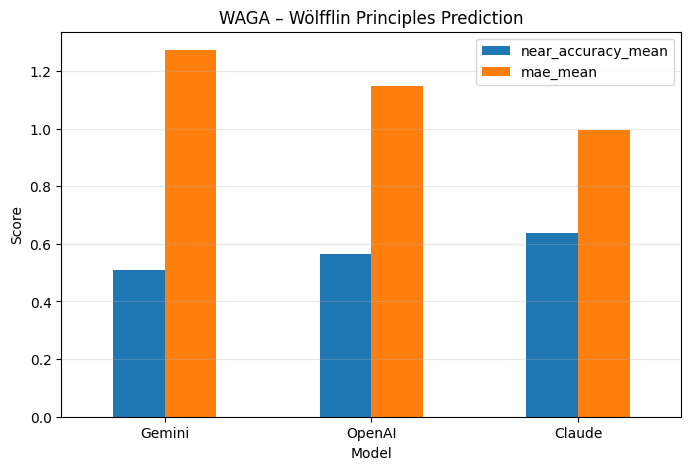

In [ ]:
import matplotlib.pyplot as plt

plot_df = waga_comparison.set_index("model")[[
    "near_accuracy_mean",
    "mae_mean"
]]

plot_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("WAGA – Wölfflin Principles Prediction")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
waga_gemini_long = df_waga_gem_valid.copy()

waga_gemini_long["dataset"] = "WAGA"
waga_gemini_long["model"] = "Gemini"

In [ ]:
waga_openai_long = df_waga_open_valid.copy()

waga_openai_long["dataset"] = "WAGA"
waga_openai_long["model"] = "OpenAI"

In [ ]:
waga_claude_long = df_waga_claude_valid.copy()

waga_claude_long["dataset"] = "WAGA"
waga_claude_long["model"] = "Claude"

In [ ]:
waga_master_long = pd.concat([
    waga_gemini_long,
    waga_openai_long,
    waga_claude_long
], ignore_index=True)

print(waga_master_long.shape)
display(waga_master_long.head())

(2996, 16)


,dataset,model,timestamp_utc,image_id,art_url,true_linear_vs_painterly,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,gemini_raw,ok,error,openai_raw,claude_raw
0,WAGA,Gemini,2026-03-08T17:04:40.803691+00:00,1,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,3.6,2.2,1.8,1.2,"{'artist_guess': ['Giulio Romano', 'Parmigiani...","{\n ""artist_guess"": [\n ""Giulio Romano"",\n...",True,NaN,NaN,NaN
1,WAGA,Gemini,2026-03-08T17:04:53.229271+00:00,2,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.6,3.8,2.2,5.0,4.6,"{'artist_guess': ['Tintoretto', 'Paolo Verones...","{\n ""artist_guess"": [\n ""Tintoretto"",\n ...",True,NaN,NaN,NaN
2,WAGA,Gemini,2026-03-08T17:05:04.407210+00:00,3,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.8,2.2,1.8,2.0,1.2,"{'artist_guess': ['Rembrandt van Rijn', 'Frans...","{\n ""artist_guess"": [\n ""Rembrandt van Rij...",True,NaN,NaN,NaN
3,WAGA,Gemini,2026-03-08T17:05:11.238690+00:00,4,https://crw2020.s3-us-west-2.amazonaws.com/ran...,3.2,1.2,1.8,2.8,4.0,"{'artist_guess': ['Andrea Mantegna', 'Carlo Cr...","{\n ""artist_guess"": [\n ""Andrea Mantegna"",...",True,NaN,NaN,NaN
4,WAGA,Gemini,2026-03-08T17:05:20.258780+00:00,5,https://crw2020.s3-us-west-2.amazonaws.com/ran...,4.0,2.8,4.0,3.6,3.4,"{'artist_guess': ['Paul Signac', 'Camille Piss...","{\n ""artist_guess"": [\n ""Paul Signac"",\n ...",True,NaN,NaN,NaN


In [ ]:
wikiart_master_long = pd.read_csv("/content/wikiart_master_predictions_long.csv")

print(wikiart_master_long.shape)

(20576, 24)


In [ ]:
final_master_dataset = pd.concat([
    wikiart_master_long,
    waga_master_long
], ignore_index=True)

print(final_master_dataset.shape)
display(final_master_dataset.head())

(23572, 38)


,dataset,model,image,img_url,true_artist,true_macro_style,true_genre,pred_artist_1,pred_artist_2,pred_artist_3,...,true_planar_vs_recessional,true_closed_vs_open_form,true_multiplicity_vs_unity,true_absolute_vs_relative,pred,gemini_raw,ok,error,openai_raw,claude_raw
0,WikiArt,Gemini,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,Impressionism,landscape,J. Alden Weir,John Twachtman,Childe Hassam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WikiArt,Gemini,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Expressionism,portrait,Arpana Caur,Kiki Smith,Frida Kahlo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WikiArt,Gemini,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Naïve / Outsider,other,Hans Hartung,Pierre Soulages,Wols,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,WikiArt,Gemini,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Romanticism,portrait,Jean-Baptiste Isabey,Daniel Saint,Sir William Ross,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,WikiArt,Gemini,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Baroque,portrait,Sir Godfrey Kneller,Jonathan Richardson the Elder,Joseph Highmore,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_master_dataset.to_csv(
    "LLM_art_history_final_dataset.csv",
    index=False
)

print("Dataset finale salvato.")

Dataset finale salvato.
